# Making a mesh

**What this shows:** how the mesh used by these notebooks was made, from a
bathymetry dataset to `hgrid.gr3`, and what to check before using a mesh.

**Prerequisites:** [Tutorial 2: The mesh and the vertical grid](../tutorial/02_mesh_and_vertical_grid.ipynb).

**You will learn:**

- the steps from bathymetry to a SCHISM mesh: water area, element size,
  triangulation, depths, open boundary
- how the element size follows the coast
- what to check in a new mesh

**Data used:** `etopo15s_perth.nc` and `make_mesh.py`. Meshing needs
[gmsh](https://gmsh.info) (`pip install gmsh`); without it, the notebook shows the
committed `hgrid.gr3` instead.

rompy-schism does not make meshes: it takes an `hgrid.gr3`. Meshes are made with
dedicated tools, such as gmsh, [OceanMesh2D](https://github.com/CHLNDDEV/OceanMesh2D)
or SMS. This notebook uses the functions of `make_mesh.py`, next to the data, which
made `hgrid.gr3`.

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import xarray as xr
from pylib import read_schism_hgrid

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "making_a_mesh"
OUT_DIR.mkdir(parents=True, exist_ok=True)
ASPECT = 1 / np.cos(np.radians(32))

sys.path.insert(0, str(DATA_DIR))
import make_mesh  # noqa: E402

try:
    import gmsh  # noqa: F401

    HAS_GMSH = True
except ImportError:
    HAS_GMSH = False
print(f"gmsh available: {HAS_GMSH}")

gmsh available: True


## 1. The bathymetry and the domain

ETOPO 2022 at 15 arc-seconds (about 450 m), land and sea together. The domain is a
box from the coast to the edge of the continental shelf: its west, north and south
sides will be the open boundary.

[Text(0.5, 1.0, 'ETOPO 2022 and the domain'), None]

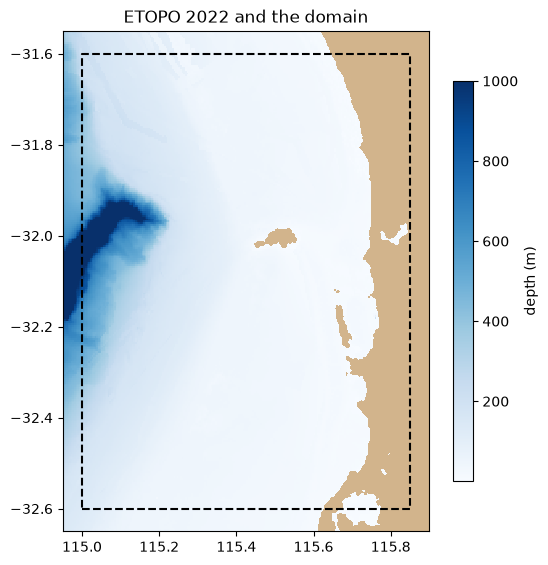

In [2]:
etopo = xr.open_dataset(DATA_DIR / "etopo15s_perth.nc").sel(
    longitude=slice(make_mesh.WEST - 0.05, make_mesh.EAST + 0.05),
    latitude=slice(make_mesh.SOUTH - 0.05, make_mesh.NORTH + 0.05),
)
lon, lat, elevation = etopo.longitude.values, etopo.latitude.values, etopo.z.values
fig, ax = plt.subplots(figsize=(6, 6.5))
sea = ax.pcolormesh(
    lon, lat, np.ma.masked_less_equal(-elevation, 0), cmap="Blues", vmax=1000
)
fig.colorbar(sea, ax=ax, label="depth (m)", shrink=0.8)
ax.contourf(lon, lat, elevation, levels=[0, 1e4], colors="tan")
west, east, south, north = make_mesh.WEST, make_mesh.EAST, make_mesh.SOUTH, make_mesh.NORTH
ax.plot([west, east, east, west, west], [south, south, north, north, south], "k--")
ax.set(title="ETOPO 2022 and the domain", aspect=ASPECT)

## 2. The water area

`water_polygon` takes the box minus the land (elevation at or above 0 m), keeps
islands larger than `MIN_ISLAND_AREA` as holes (Rottnest, in two parts because ETOPO
separates its narrow western end, and Garden Island), and simplifies the coastline to
about `SIMPLIFY` degrees (200 m). Smaller features than that cannot be resolved by
the elements anyway, and would make gmsh add tiny elements to follow them.

[Text(0.5, 1.0, 'Water area, with 3 holes'), None]

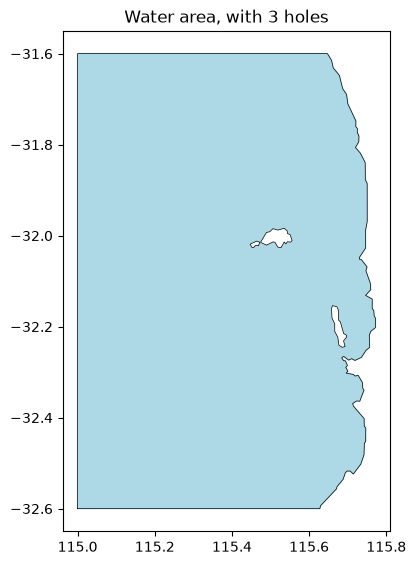

In [3]:
water = make_mesh.water_polygon(lon, lat, elevation)
fig, ax = plt.subplots(figsize=(6, 6.5))
ax.fill(*water.exterior.xy, color="lightblue")
for ring in water.interiors:
    ax.fill(*ring.xy, color="white", edgecolor="k", linewidth=0.5)
ax.plot(*water.exterior.xy, "k", linewidth=0.5)
ax.set(title=f"Water area, with {len(water.interiors)} holes", aspect=ASPECT)

## 3. Element size

Resolution is needed where things change quickly: at the coast, around islands and
in the passages between them. Offshore, larger elements are enough. The size grows
with the distance to the coast (not to the open boundary):

| Setting | Value | Meaning |
|---|---|---|
| `SIZE_COAST` | 0.004° (about 400 m) | element size along the coast |
| `SIZE_OFFSHORE` | 0.025° (about 2.5 km) | the largest elements |
| `GROWTH_DISTANCE` | 0.2° (about 20 km) | distance from the coast over which the size grows |

## 4. Triangulation

gmsh fills the water area with triangles of that size. `triangulate` returns the
nodes and triangles, counter-clockwise as SCHISM needs them.

In [4]:
if HAS_GMSH:
    nodes, triangles = make_mesh.triangulate(water)
    print(f"{len(nodes)} nodes, {len(triangles)} triangles")

6790 nodes, 12958 triangles


## 5. Depths and the open boundary

`main` runs all the steps and writes `hgrid.gr3`:

- depths are interpolated from ETOPO at the nodes, positive down;
- the open boundary goes round the sea from the coast at the north-east corner to
  the coast at the south-east corner; the coast and the islands are land
  boundaries;
- open boundary nodes are at least `MIN_OPEN_BOUNDARY_DEPTH` (2 m) deep: SCHISM
  stops if an open boundary node dries.

With the same inputs it writes the same mesh as the one committed.

In [5]:
if HAS_GMSH:
    hgrid_file = OUT_DIR / "hgrid.gr3"
    make_mesh.main(DATA_DIR / "etopo15s_perth.nc", str(hgrid_file))
    same = hgrid_file.read_bytes() == (DATA_DIR / "hgrid.gr3").read_bytes()
    print(f"Same as the committed hgrid.gr3: {same}")
else:
    hgrid_file = DATA_DIR / "hgrid.gr3"

_output/making_a_mesh/hgrid.gr3: 6790 nodes, 12958 elements, 1 open boundary (115 nodes), 4 land boundaries
Same as the committed hgrid.gr3: True


## 6. Checking the mesh

Before using a new mesh, look at:

- **the element size**, where the model needs resolution;
- **the depths**, and the open boundary: deep enough, and crossing the flow
  smoothly;
- **element quality**: very thin triangles (small angles) make the numerics less
  accurate;
- **the Courant number** for the time step you will use, √(gh)·Δt/Δx. SCHISM's
  semi-implicit scheme has no upper limit on it, unlike explicit models; the
  [SCHISM manual](https://schism-dev.github.io/schism/master/) recommends the
  opposite check, a Courant number above about 0.4, which small elements in
  shallow water can fail with a short time step.

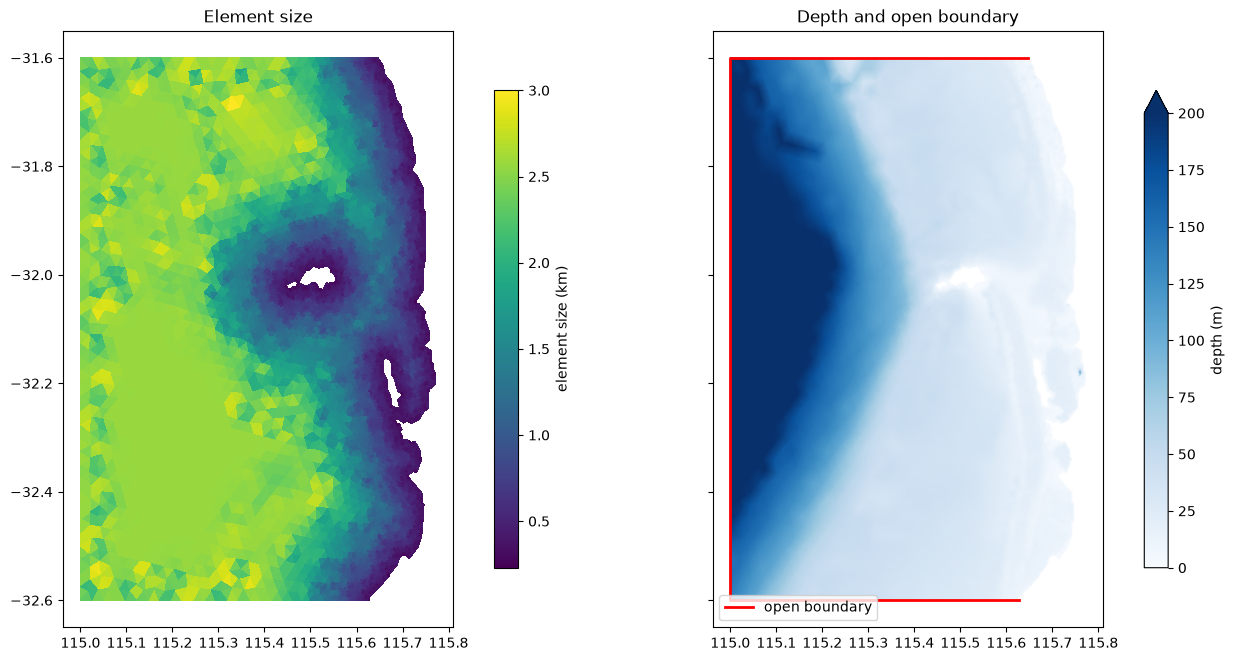

In [6]:
hgrid = read_schism_hgrid(str(hgrid_file))
hgrid.compute_bnd()
triangulation = mtri.Triangulation(hgrid.x, hgrid.y, hgrid.elnode[:, :3])
x, y = hgrid.x[hgrid.elnode[:, :3]], hgrid.y[hgrid.elnode[:, :3]]
dx = (x - np.roll(x, -1, axis=1)) * 111e3 / ASPECT
dy = (y - np.roll(y, -1, axis=1)) * 111e3
sides = np.hypot(dx, dy)
size = sides.mean(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharey=True, layout="constrained")
tpc = axes[0].tripcolor(triangulation, size / 1000, cmap="viridis", vmax=3)
fig.colorbar(tpc, ax=axes[0], label="element size (km)", shrink=0.8)
tpc = axes[1].tripcolor(
    triangulation, hgrid.dp, cmap="Blues", shading="gouraud", vmin=0, vmax=200
)
fig.colorbar(tpc, ax=axes[1], label="depth (m)", shrink=0.8, extend="max")
open_nodes = hgrid.iobn[0]
axes[1].plot(hgrid.x[open_nodes], hgrid.y[open_nodes], "r", linewidth=2, label="open boundary")
axes[1].legend(loc="lower left")
for ax, title in zip(axes, ["Element size", "Depth and open boundary"]):
    ax.set(title=title, aspect=ASPECT)

In [7]:
# Smallest angle of each triangle, from the law of cosines
a, b, c = sides[:, 0], sides[:, 1], sides[:, 2]
angles = np.degrees(
    np.arccos(np.clip(np.stack([
        (b**2 + c**2 - a**2) / (2 * b * c),
        (a**2 + c**2 - b**2) / (2 * a * c),
        (a**2 + b**2 - c**2) / (2 * a * b),
    ]), -1, 1))
)  # fmt: skip
smallest = angles.min(axis=0)
print(f"Element size: {size.min():.0f} m to {size.max():.0f} m")
print(f"Smallest angle: {smallest.min():.0f}°; below 30°: {(smallest < 30).sum()} of {len(smallest)} elements")

# Courant number with the 120 s time step of the notebooks, at element centres
dt = 120.0
depth = np.maximum(hgrid.dp[hgrid.elnode[:, :3]].mean(axis=1), 0.1)
courant = np.sqrt(9.81 * depth) * dt / size
print(f"Courant number with dt={dt:.0f} s: {np.percentile(courant, 1):.1f} to {courant.max():.0f}; below 0.4: {(courant < 0.4).sum()} elements")

Element size: 230 m to 3023 m
Smallest angle: 31°; below 30°: 0 of 12958 elements
Courant number with dt=120 s: 0.9 to 8; below 0.4: 43 elements


No thin elements, and the Courant number is above 0.4 everywhere except in a few
elements at the shore, at or above the datum, that are only wet at high tide.

## 7. Using the mesh

A new mesh is used like the committed one:

```python
grid = SCHISMGrid(hgrid=DataBlob(source="hgrid.gr3"), drag=0.0025)
```

## Summary

- rompy-schism takes a mesh; make it with a meshing tool, such as gmsh here.
- Start from the water area, simplified to the resolution you can afford.
- Grade the element size from fine at the coast to coarse offshore.
- Interpolate depths, define the open boundary, and keep it deep enough not to dry.
- Check the element size, depths and element quality before running.